In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.stats import expon



In [33]:
#leggo il file csv
vehicle_data = pd.read_csv('componente_vehicle_completo_classificato.csv')

vehicle_data['Timestamp'] = pd.to_datetime(vehicle_data['Timestamp'], errors='coerce')

vehicle_data_clean = vehicle_data.dropna(subset=['Timestamp', 'Timestamp chiusura'])

print(f"Righe rimaste dopo il filtraggio: {len(vehicle_data_clean)}")



Righe rimaste dopo il filtraggio: 14587


In [34]:
#filtro il dataset per avere solo timestamp univoci
vehicle_data_clean = vehicle_data_clean.drop_duplicates(subset=['Descrizione', 'Timestamp'])

print(f"Righe rimaste dopo la rimozione dei duplicati: {len(vehicle_data_clean)}")

vehicle_data_clean.head()

Righe rimaste dopo la rimozione dei duplicati: 4047


,Flotta,Veicolo,Codice,Nome,Descrizione,Test,Timestamp,Timestamp chiusura,Durata,Posizione,...,usB2BCilPres_M3,usB2BCilPres_M6,usB2BCilPres_M8,usB2BCilPres_T2,usB2BCilPres_T4,usB2BCilPres_T5,usB2BCilPres_T7,usBpPres,usMpPres,Tipo_Evento
18,ETR700,e700_4801,018202,CCU_FltWtbComm,Mancata comunicazione WTB in CCU M8,N,2022-03-14 13:53:13.901,2022-03-14 13:53:15.057,2.0,Milano,...,2.59,2.63,2.58,2.43,2.12,2.18,2.55,0.0,8.54,Anomalia
33,ETR700,e700_4801,018201,CCU_FltWtbR2,Mancata ricezione R2 in CCU M8,N,2022-03-14 13:53:13.901,2022-03-14 13:53:15.057,2.0,Milano,...,2.59,2.63,2.58,2.43,2.12,2.18,2.55,0.0,8.54,Anomalia
48,ETR700,e700_4801,150006,_Running_,Stato RUNNING attivo,N,2022-03-14 13:46:36.703,2022-03-14 13:53:14.106,398.0,NaN,...,2.60,2.63,2.58,2.43,2.13,2.19,2.56,0.0,9.25,Funzionamento Normale
51,ETR700,e700_4801,ILCK_PROP_04,ILCK_PROP_04,Cod. 04 Condotta Generale scarica,N,2022-03-14 13:46:36.501,2022-03-14 13:53:13.901,398.0,Milano,...,2.60,2.63,2.58,2.43,2.13,2.19,2.56,0.0,9.25,Anomalia
54,ETR700,e700_4801,018202,CCU_FltWtbComm,Mancata comunicazione WTB in CCU M8,N,2022-03-14 13:46:36.297,2022-03-14 13:46:38.698,3.0,Milano,...,2.60,2.63,2.58,2.43,2.13,2.19,2.56,0.0,9.25,Anomalia


In [37]:
#calcolo il tempo di interarrivo medio tra le anomalie
anomalies = vehicle_data_clean[vehicle_data_clean['Tipo_Evento'] == 'Anomalia']

anomalies_sorted = anomalies.sort_values(by='Timestamp')

anomalies_sorted['Interarrival_Time'] = anomalies_sorted['Timestamp'].diff().dt.total_seconds()

anomalies_interarrival = anomalies_sorted['Interarrival_Time'].dropna()

mean_interarrival = anomalies_interarrival.mean()
print(f"Media dei tempi di interarrivo in secondi: {mean_interarrival}")



Media dei tempi di interarrivo in secondi: 205.31376218323587


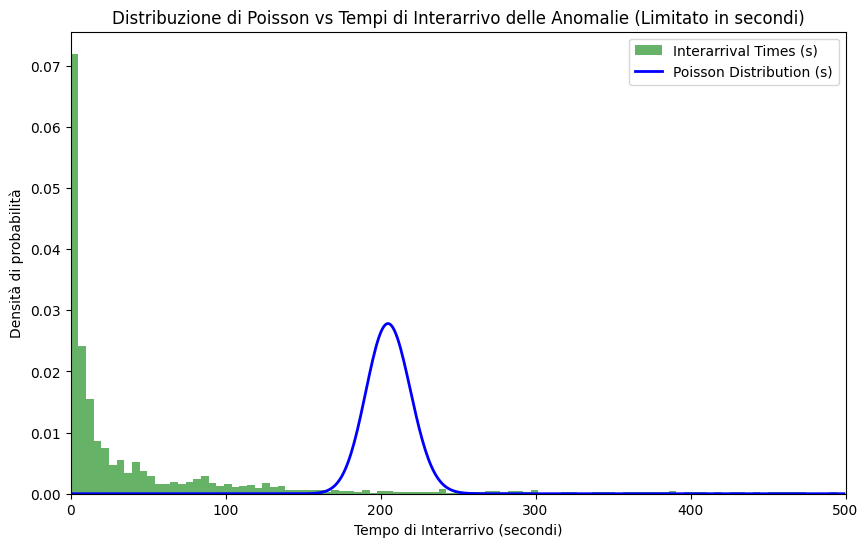

In [48]:
#distribuzione di Poisson sui tempi di interarrivo
lambda_poisson = anomalies_interarrival.mean()

x_limit = 500

anomalies_interarrival_limited = anomalies_interarrival[anomalies_interarrival <= x_limit]

poisson_distribution = poisson.pmf(range(x_limit), lambda_poisson)

plt.figure(figsize=(10,6))
plt.hist(anomalies_interarrival_limited, bins=100, density=True, alpha=0.6, color='g', label='Interarrival Times (s)')
plt.plot(range(x_limit), poisson_distribution, 'b-', lw=2, label='Poisson Distribution (s)')
plt.title('Distribuzione di Poisson vs Tempi di Interarrivo delle Anomalie (Limitato in secondi)')
plt.xlabel('Tempo di Interarrivo (secondi)')
plt.ylabel('Densità di probabilità')
plt.xlim(0, x_limit)
plt.legend()
plt.show()

In [40]:
#calcola valore mediana
median_interarrival = anomalies_interarrival.median()
print(f"Mediana dei tempi di interarrivo in secondi: {median_interarrival}")

Mediana dei tempi di interarrivo in secondi: 12.600000000000001


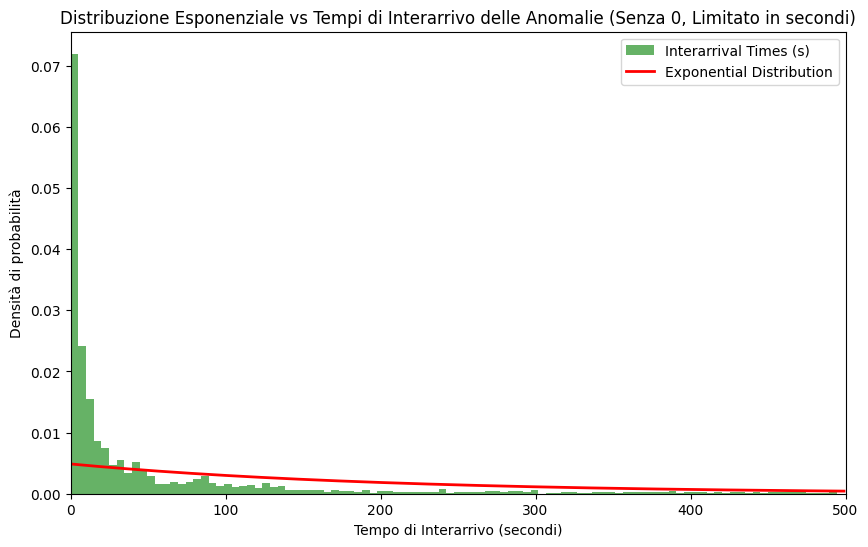

In [51]:
#distribuzione esponenziale sui tempi di interarrivo
lambda_expon = 1 / anomalies_interarrival.mean()

expon_distribution = expon.pdf(range(x_limit), scale=1/lambda_expon)

plt.figure(figsize=(10,6))
plt.hist(anomalies_interarrival_limited, bins=100, density=True, alpha=0.6, color='g', label='Interarrival Times (s)')
plt.plot(range(x_limit), expon_distribution, 'r-', lw=2, label='Exponential Distribution')
plt.title('Distribuzione Esponenziale vs Tempi di Interarrivo delle Anomalie (Senza 0, Limitato in secondi)')
plt.xlabel('Tempo di Interarrivo (secondi)')
plt.ylabel('Densità di probabilità')
plt.xlim(0, x_limit)
plt.legend()
plt.show()

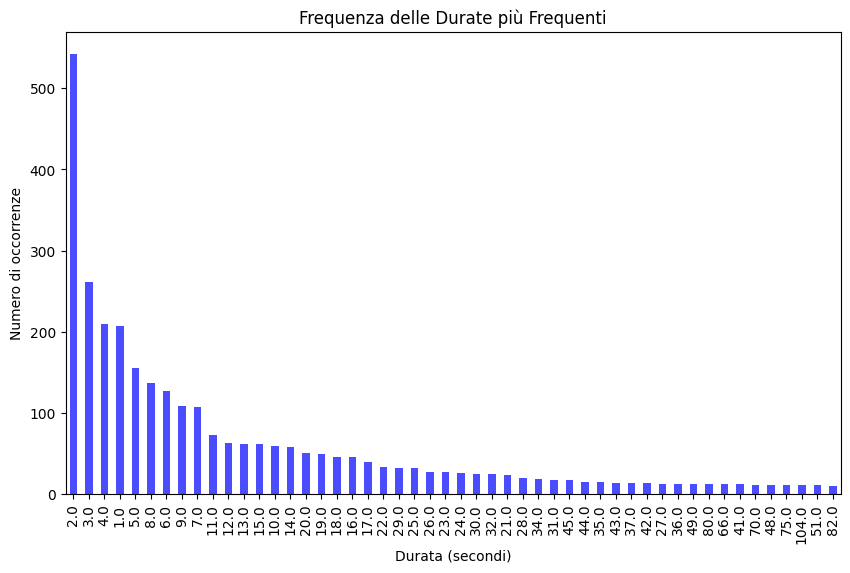

In [58]:
#grafico delle frequenze delle durate delle anomalie
durata_counts = vehicle_data_clean['Durata'].value_counts()
top_durata_counts = durata_counts.head(50)

plt.figure(figsize=(10,6))
top_durata_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Frequenza delle Durate più Frequenti')
plt.xlabel('Durata (secondi)')
plt.ylabel('Numero di occorrenze')
plt.show()